In [18]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Set style for better-looking plots with colorblind-friendly palette
sns.set_style("whitegrid")
sns.set_palette("colorblind")  # Colorblind-friendly palette
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

Heuristics found: ['chebyshev', 'euclidean', 'manhattan']
Data shape: (33, 3)

    heuristic  cluster_size  max_memory
0   chebyshev             1       3.206
1   chebyshev           100       3.206
2   chebyshev           200       3.204
3   chebyshev           300       3.191
4   chebyshev           400       3.190
5   chebyshev           500       3.201
6   chebyshev           600       3.196
7   chebyshev           700       3.203
8   chebyshev           800       3.191
9   chebyshev           900       3.206
10  chebyshev          1000       3.200
11  euclidean             1       3.212
12  euclidean           100       3.207
13  euclidean           200       3.207
14  euclidean           300       3.208


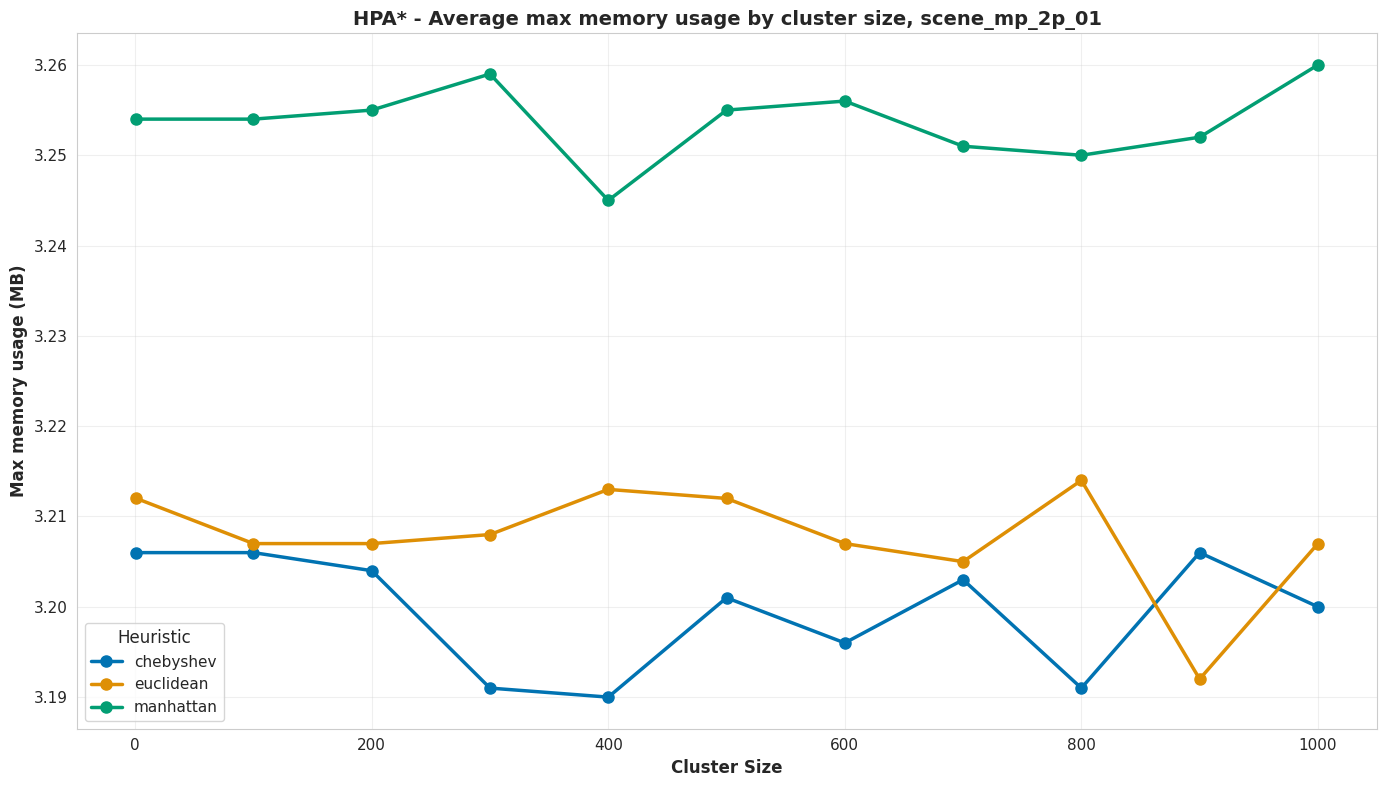

In [22]:
# Read all files in results/ starting with mp2
results_path = Path('results')
files = sorted(results_path.glob('mp2*.json'))

# Load and combine data from all files
df_list = []
for file in files:
    # Extract heuristic from filename (mp2-hpa-{HEURISTIC}.json)
    filename = file.stem  # e.g., 'mp2-hpa-euc'
    heuristic = filename.split('-')[-1].lower()  # Extract last part and uppercase
    
    with open(file, 'r') as f:
        content = json.load(f)
        # Extract data array
        if 'data' in content and isinstance(content['data'], list):
            for data_point in content['data']:
                row = {
                    'heuristic': heuristic,
                    'cluster_size': data_point.get('cluster_size'),
                    'max_memory': data_point.get('timings', {}).get('max_memory'),
                }
                df_list.append(row)

df_mem = pd.DataFrame(df_list)

# Group by heuristic and cluster_size to get average memory usage
df_grouped = df_mem.groupby(['heuristic', 'cluster_size'])['max_memory'].mean().reset_index()

print(f"Heuristics found: {sorted(df_grouped['heuristic'].unique())}")
print(f"Data shape: {df_grouped.shape}\n")
print(df_grouped.head(15))

# Plot max memory usage by cluster size, one line per heuristic
fig, ax = plt.subplots(figsize=(14, 8))

for heuristic in sorted(df_grouped['heuristic'].unique()):
    heur_data = df_grouped[df_grouped['heuristic'] == heuristic].sort_values('cluster_size')
    ax.plot(heur_data['cluster_size'], heur_data['max_memory'], 
            marker='o', linewidth=2.5, markersize=8, label=heuristic)

ax.set_xlabel('Cluster Size', fontsize=12, fontweight='bold')
ax.set_ylabel('Max memory usage (MB)', fontsize=12, fontweight='bold')
ax.set_title('HPA* - Average max memory usage by cluster size, scene_mp_2p_01', fontsize=14, fontweight='bold')
# ax.set_ylim([0, 3.5])
ax.legend(title='Heuristic', fontsize=11, title_fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()